# 02 — Análise Descritiva

**Entrada**: `data/processed/anonymized.csv` (e long-form auxiliares)

**Saídas**: figuras PDF em `figures/` + tabelas em `data/processed/tables/`

**Objetivos**:
- Tabela 2 demográfica consolidada (substitui 3 figuras)
- Diverging stacked bar para skills (Q8), importância (Q11), prioridade (Q13)
- Frequência de discussão e suporte (Q19, Q22)
- Bar chart palavras Q9 (frequência bruta — lematização vai pro 04)
- Tabela com IC 95% Wilson para todas as proporções principais
- Substituir os 11 placeholders `example-image-duck`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importância={len(imp_long)}, prioridade={len(pri_long)}")

N=32, importância=416, prioridade=416


## 1. Tabela 2 — Caracterização demográfica

Consolida em **uma tabela** o que estavam 3 figuras (gênero/papel/idade) + senioridade + escolaridade + projetos + região. Saída: LaTeX para `tables/`.

In [2]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Categoria": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variável", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender"], "Gênero"),
    freq_table(df["age"], "Faixa etária",
               order=["18-24 anos", "25-34 anos", "35-44 anos", "45-54 anos", "55-64 anos"]),
    freq_table(df["region"], "Região",
               order=["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]),
    freq_table(df["education"], "Escolaridade"),
    freq_table(df["role_group"], "Papel"),
    freq_table(df["seniority"], "Senioridade",
               order=list(U.SENIORITY_ORDINAL.keys())),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variável,Categoria,n,%
0,Gênero,Homem,24,75.0
1,,Mulher,8,25.0
2,Faixa etária,18-24 anos,5,15.6
3,,25-34 anos,17,53.1
4,,35-44 anos,7,21.9
5,,45-54 anos,3,9.4
6,Região,Norte,1,3.1
7,,Nordeste,23,71.9
8,,Sudeste,6,18.8
9,,Sul,2,6.2


In [3]:
# # projetos: stats descritivas
proj = df["n_projects"]
proj_stats = pd.Series({
    "min": int(proj.min()),
    "Q1": float(proj.quantile(0.25)),
    "mediana": float(proj.median()),
    "Q3": float(proj.quantile(0.75)),
    "max": int(proj.max()),
    "média": float(proj.mean()),
})
print("Projetos AM já participados:")
print(proj_stats.round(1).to_string())

Projetos AM já participados:
min         0.0
Q1          2.0
mediana     3.5
Q3          8.5
max        40.0
média       7.0


In [4]:
# Salvar tabela LaTeX que vai entrar como Tabela 2 no paper
def df_to_latex_demo(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Caracterização dos respondentes ($n=32$).}",
        "\\label{tab:demographics}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lp{4.5cm}rr}",
        "\\toprule",
        "\\textbf{Variável} & \\textbf{Categoria} & \\textbf{n} & \\textbf{\\%} \\\\",
        "\\midrule",
    ]
    for _, row in df.iterrows():
        var = row["Variável"] if row["Variável"] else ""
        cat = str(row["Categoria"]).replace("_", "\\_")
        lines.append(f"{var} & {cat} & {row['n']} & {row['%']:.1f} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "demographics.tex").write_text(df_to_latex_demo(demo_table))
print("[saved] tables/demographics.tex")

[saved] tables/demographics.tex


## 2. Diverging stacked bar — função genérica

Centraliza Likerts em Neutro=0. Negativos vão pra esquerda, positivos pra direita.

In [5]:
def diverging_stacked(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    item_labels: dict[str, str],
    level_labels: list[str],
    title: str,
    figsize: tuple[float, float] = (7.0, 4.5),
    palette: list[str] | None = None,
    sort_by_positive: bool = True,
) -> plt.Figure:
    """Diverging stacked bar para Likerts.

    long_df: long format com colunas [item_col, value_col]; value_col é int 1..N
    item_labels: dict de chave (no item_col) → rótulo bonito pro eixo y
    level_labels: lista de N rótulos (1ª = mais negativo). Se 5 níveis, 3º é o neutro.
    """
    n_levels = len(level_labels)
    if palette is None:
        palette = U.PALETTE_LIKERT_5 if n_levels == 5 else None
    items = list(item_labels.keys())
    counts = (long_df.groupby(item_col)[value_col]
              .value_counts().unstack(fill_value=0)
              .reindex(index=items, columns=range(1, n_levels + 1), fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    if sort_by_positive:
        positive = pct[[n_levels - 1, n_levels]] if n_levels >= 4 else pct[[n_levels]]
        order = positive.sum(axis=1).sort_values().index
        pct = pct.loc[order]
        items = list(order)
    # Centro: para 5 níveis, neutro é o 3 (índice central). Negativos {1,2}, Positivos {4,5}.
    if n_levels == 5:
        neg_levels, neutral, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked espera 4 ou 5 níveis")

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(items))
    # Negativos: empilhar com sinal trocado, do mais externo (1) ao mais central (2)
    left_offset = -pct[neg_levels[1]].values - pct[neg_levels[0]].values
    cur = left_offset.copy()
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths
    if neutral is not None:
        widths = pct[neutral].values
        # Centrar o neutro em torno de 0
        ax.barh(y, widths, left=-widths / 2, color=palette[neutral - 1],
                edgecolor="white", linewidth=0.5, label=level_labels[neutral - 1])
    cur = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([item_labels[i] for i in items])
    ax.set_xlabel("% das respostas")
    ax.set_xlim(-100, 100)
    ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["100%", "75%", "50%", "25%", "0", "25%", "50%", "75%", "100%"])
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=n_levels, frameon=False)
    return fig

## 3. Skills (Q8) — substitui 5 figuras por 1

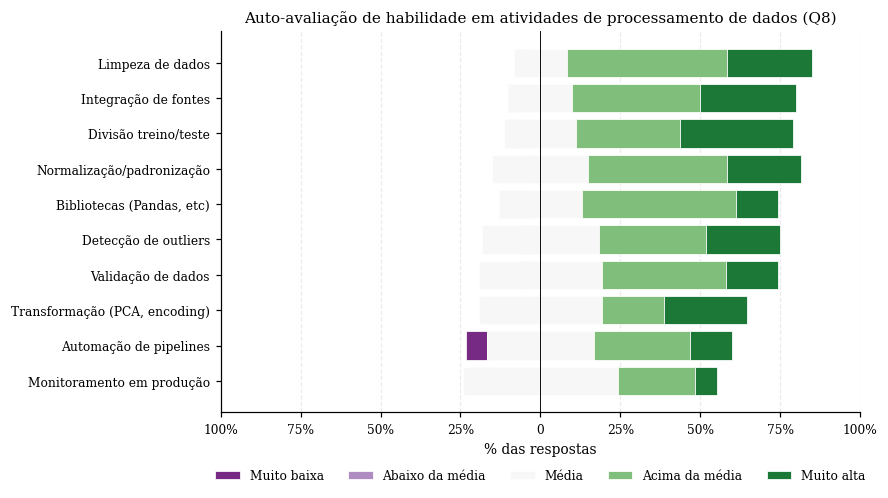

In [6]:
skills_renamed = skills_long.copy()
fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Muito baixa", "Abaixo da média", "Média", "Acima da média", "Muito alta"],
    title="Auto-avaliação de habilidade em atividades de processamento de dados (Q8)",
    figsize=(7.5, 4.5),
)
U.save_fig(fig, "skills_diverging")
plt.show()

## 4. Importância (Q11) — 13 características

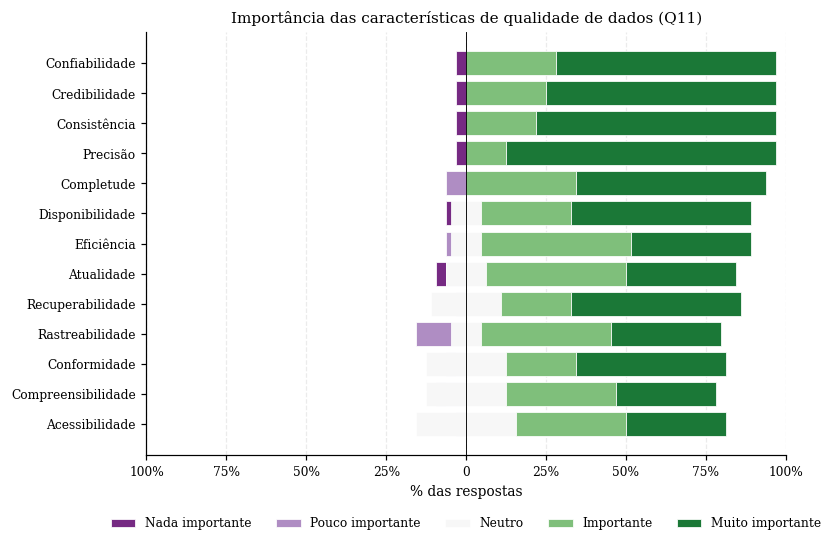

In [7]:
imp_renamed = imp_long.copy()
fig = diverging_stacked(
    imp_renamed,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Nada importante", "Pouco importante", "Neutro", "Importante", "Muito importante"],
    title="Importância das características de qualidade de dados (Q11)",
    figsize=(7.5, 5.0),
)
U.save_fig(fig, "importance_diverging")
plt.show()

## 5. Prioridade (Q13) — 13 características

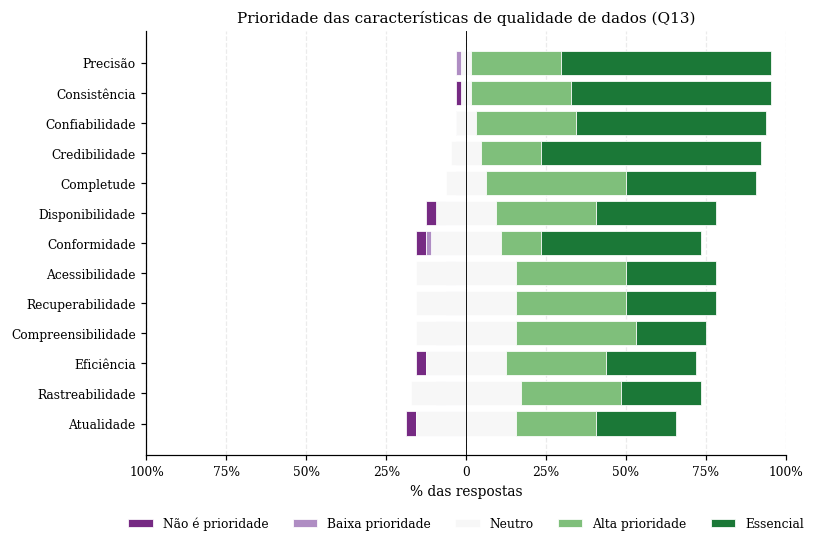

In [8]:
fig = diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Não é prioridade", "Baixa prioridade", "Neutro", "Alta prioridade", "Essencial"],
    title="Prioridade das características de qualidade de dados (Q13)",
    figsize=(7.5, 5.0),
)
U.save_fig(fig, "priority_diverging")
plt.show()

## 6. Importância vs Prioridade — comparação direta

Lado-a-lado: % "Muito importante/Importante" vs % "Essencial/Alta prioridade". Mostra o gap entre o que é considerado importante e o que é tratado como prioritário.

In [9]:
imp_top = (imp_long.groupby("characteristic")["importance"]
           .apply(lambda s: ((s >= 4).sum() / len(s)) * 100))
pri_top = (pri_long.groupby("characteristic")["priority"]
           .apply(lambda s: ((s >= 4).sum() / len(s)) * 100))
comp = pd.DataFrame({"% Importante/Muito": imp_top, "% Alta/Essencial": pri_top})
comp["gap"] = comp["% Importante/Muito"] - comp["% Alta/Essencial"]
comp = comp.reindex(index=list(U.CHARACTERISTICS_PT.keys()))
comp.index = [U.CHARACTERISTICS_PT[c] for c in comp.index]
comp = comp.sort_values("% Importante/Muito")
comp.round(1)

,% Importante/Muito,% Alta/Essencial,gap
Acessibilidade,65.6,62.5,3.1
Compreensibilidade,65.6,59.4,6.2
Conformidade,68.8,62.5,6.2
Rastreabilidade,75.0,56.2,18.8
Recuperabilidade,75.0,62.5,12.5
Atualidade,78.1,50.0,28.1
Eficiência,84.4,59.4,25.0
Disponibilidade,84.4,68.8,15.6
Completude,93.8,84.4,9.4
Precisão,96.9,93.8,3.1


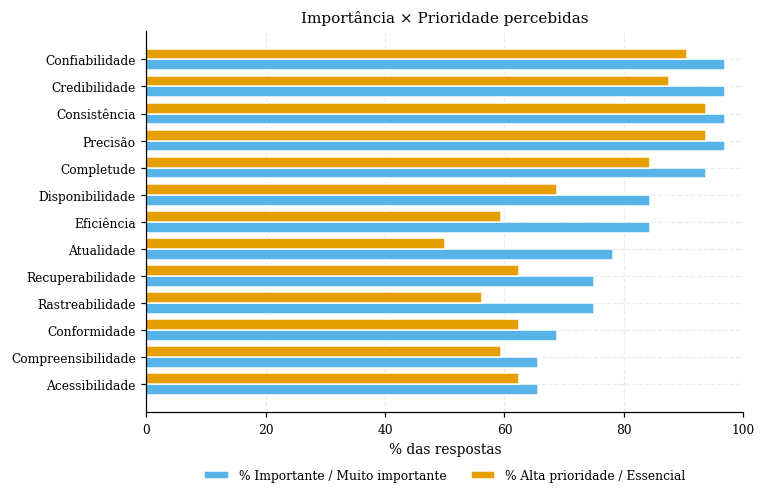

In [10]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
y = np.arange(len(comp))
h = 0.4
ax.barh(y - h/2, comp["% Importante/Muito"], h,
        color=U.PALETTE_WONG[2], label="% Importante / Muito importante", edgecolor="white")
ax.barh(y + h/2, comp["% Alta/Essencial"], h,
        color=U.PALETTE_WONG[1], label="% Alta prioridade / Essencial", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.set_xlabel("% das respostas")
ax.set_xlim(0, 100)
ax.set_title("Importância × Prioridade percebidas")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
U.save_fig(fig, "importance_vs_priority")
plt.show()

## 7. Frequências (Q19 discussão + Q22 suporte)

Duas distribuições em 1 figura compartilhando estética.

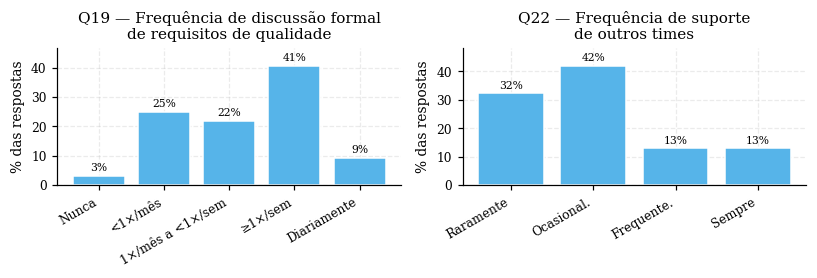

In [11]:
disc_labels = ["Nunca", "<1×/mês", "1×/mês a <1×/sem", "≥1×/sem", "Diariamente"]
supp_labels = ["Raramente", "Ocasional.", "Frequente.", "Sempre"]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.6))

for ax, col, labels, title in [
    (axes[0], "discussion_freq", disc_labels,
     "Q19 — Frequência de discussão formal\nde requisitos de qualidade"),
    (axes[1], "support_freq", supp_labels,
     "Q22 — Frequência de suporte\nde outros times"),
]:
    counts = df[col].value_counts(dropna=False).reindex(range(1, len(labels) + 1), fill_value=0)
    pct = counts / counts.sum() * 100
    ax.bar(range(len(labels)), pct.values, color=U.PALETTE_WONG[2], edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("% das respostas")
    ax.set_title(title)
    ax.set_ylim(0, max(pct.values) * 1.15)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
U.save_fig(fig, "frequencies")
plt.show()

## 8. Palavras Q9 — frequência bruta + por posição

Lematização e tratamento avançado vão pro notebook 04. Aqui só visão geral.

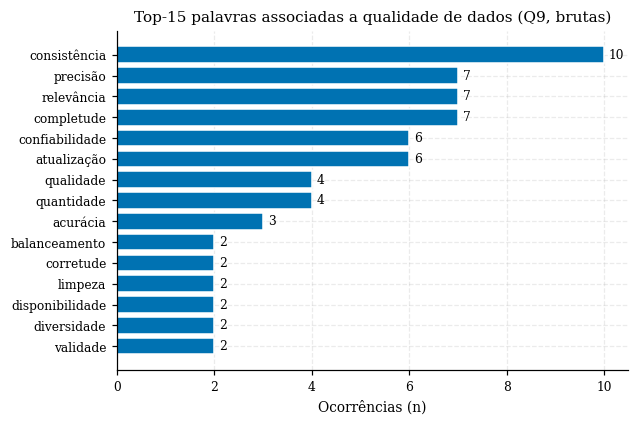

In [12]:
# Top-15 palavras geral
top = words["word"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.barh(range(len(top)), top.values[::-1], color=U.PALETTE_WONG[5], edgecolor="white")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index[::-1])
ax.set_xlabel("Ocorrências (n)")
ax.set_title("Top-15 palavras associadas a qualidade de dados (Q9, brutas)")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=8)
U.save_fig(fig, "words_top15")
plt.show()

## 9. Tabela com IC 95% Wilson para proporções principais

In [13]:
rows = []
for char_key, char_label in U.CHARACTERISTICS_PT.items():
    imp_col = f"imp_{char_key}"
    pri_col = f"pri_{char_key}"
    n_imp = df[imp_col].notna().sum()
    n_pri = df[pri_col].notna().sum()
    suc_imp = (df[imp_col] >= 4).sum()
    suc_pri = (df[pri_col] >= 4).sum()
    lo_i, hi_i = U.wilson_ci(int(suc_imp), int(n_imp))
    lo_p, hi_p = U.wilson_ci(int(suc_pri), int(n_pri))
    rows.append({
        "Característica": char_label,
        "% Importante/Muito": f"{suc_imp/n_imp*100:.0f}%",
        "IC95 (imp.)": f"[{lo_i*100:.0f}–{hi_i*100:.0f}]",
        "% Alta/Essencial": f"{suc_pri/n_pri*100:.0f}%",
        "IC95 (pri.)": f"[{lo_p*100:.0f}–{hi_p*100:.0f}]",
        "n": int(n_imp),
    })
ci_table = pd.DataFrame(rows)
# Ordenar pelo % importância
ci_table["_sort"] = ci_table["% Importante/Muito"].str.rstrip("%").astype(float)
ci_table = ci_table.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
ci_table

,Característica,% Importante/Muito,IC95 (imp.),% Alta/Essencial,IC95 (pri.),n
0,Precisão,97%,[84–99],94%,[80–98],32
1,Consistência,97%,[84–99],94%,[80–98],32
2,Credibilidade,97%,[84–99],88%,[72–95],32
3,Confiabilidade,97%,[84–99],91%,[76–97],32
4,Completude,94%,[80–98],84%,[68–93],32
5,Disponibilidade,84%,[68–93],69%,[51–82],32
6,Eficiência,84%,[68–93],59%,[42–74],32
7,Atualidade,78%,[61–89],50%,[34–66],32
8,Rastreabilidade,75%,[58–87],56%,[39–72],32
9,Recuperabilidade,75%,[58–87],62%,[45–77],32


In [14]:
# Tabela LaTeX com proporções + IC
def df_to_latex_ci(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Proporções de respostas \\textit{Importante/Muito importante} (Q11) e \\textit{Alta prioridade/Essencial} (Q13) com IC 95\\% Wilson ($n=32$).}",
        "\\label{tab:characteristics-ci}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lcccc}",
        "\\toprule",
        "\\textbf{Característica} & \\textbf{\\% Imp.} & \\textbf{IC 95\\%} & \\textbf{\\% Pri.} & \\textbf{IC 95\\%} \\\\",
        "\\midrule",
    ]
    for _, r in df.iterrows():
        lines.append(f"{r['Característica']} & {r['% Importante/Muito']} & {r['IC95 (imp.)']} & {r['% Alta/Essencial']} & {r['IC95 (pri.)']} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "characteristics_ci.tex").write_text(df_to_latex_ci(ci_table))
print("[saved] tables/characteristics_ci.tex")

[saved] tables/characteristics_ci.tex


## 10. Heatmap subgrupos × características (% top-2)

Linhas = subgrupo, colunas = característica, valor = % "Importante/Muito importante". Marca diferenças visuais rápido (estilo Diversity Matters).

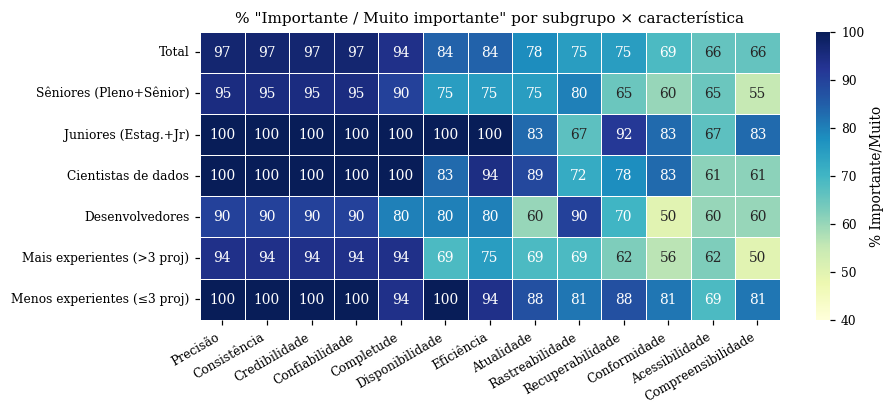

In [15]:
def pct_top2(df_sub: pd.DataFrame, col: str) -> float:
    s = df_sub[col].dropna()
    if len(s) == 0:
        return float("nan")
    return (s >= 4).sum() / len(s) * 100

groups = {
    "Total": df,
    "Sêniores (Pleno+Sênior)": df[df["seniority_group"] == "senior"],
    "Juniores (Estag.+Jr)": df[df["seniority_group"] == "junior"],
    "Cientistas de dados": df[df["role_group"] == "data_scientist"],
    "Desenvolvedores": df[df["role_group"] == "developer"],
    "Mais experientes (>3 proj)": df[df["n_projects"] > 3],
    "Menos experientes (≤3 proj)": df[df["n_projects"] <= 3],
}

heat = pd.DataFrame(
    {label: [pct_top2(g, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()] for label, g in groups.items()},
    index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()],
).T
# Ordenar colunas pelo % do total
heat = heat[heat.loc["Total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Importante/Muito"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=40, vmax=100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("% \"Importante / Muito importante\" por subgrupo × característica")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_importance_subgroups")
plt.show()

## 11. Skills agregadas — % "Acima da média/Muito alta"

In [16]:
skill_pct = []
for col in U.SKILL_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    high = (s >= 4).sum()
    lo, hi = U.wilson_ci(int(high), int(len(s)))
    skill_pct.append({
        "Atividade": U.SKILL_LABELS_PT[col],
        "% Alta": high / len(s) * 100,
        "IC95": f"[{lo*100:.0f}–{hi*100:.0f}]",
        "n": int(len(s)),
    })
skill_pct_df = pd.DataFrame(skill_pct).sort_values("% Alta", ascending=False).reset_index(drop=True)
skill_pct_df.round(1)

,Atividade,% Alta,IC95,n
0,Limpeza de dados,76.7,[59–88],30
1,Integração de fontes,70.0,[52–83],30
2,Divisão treino/teste,67.7,[50–81],31
3,Normalização/padronização,66.7,[49–81],30
4,"Bibliotecas (Pandas, etc)",61.3,[44–76],31
5,Detecção de outliers,56.7,[39–73],30
6,Validação de dados,54.8,[38–71],31
7,"Transformação (PCA, encoding)",45.2,[29–62],31
8,Automação de pipelines,43.3,[27–61],30
9,Monitoramento em produção,31.0,[17–49],29


## 12. Sumário descritivo final

In [17]:
# Achados-chave que o paper precisa citar
summary = {
    "n": len(df),
    "%_homens": (df["gender"] == "Homem").mean() * 100,
    "%_NE": (df["region"] == "Nordeste").mean() * 100,
    "%_DS": (df["role_group"] == "data_scientist").mean() * 100,
    "%_seniors": (df["seniority_group"] == "senior").mean() * 100,
    "projetos_mediana": int(df["n_projects"].median()),
    "%_disc_<1mes": ((df["discussion_freq"] <= 2).sum() / df["discussion_freq"].notna().sum() * 100),
    "%_supp_<=ocasional": ((df["support_freq"] <= 2).sum() / df["support_freq"].notna().sum() * 100),
    "caract_mais_imp": ci_table.iloc[0]["Característica"],
    "caract_menos_imp": ci_table.iloc[-1]["Característica"],
}
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.1f}")
    else:
        print(f"{k}: {v}")

import json
(TABLES / "descriptive_summary.json").write_text(json.dumps({k: (float(v) if isinstance(v, (int, float)) else v) for k, v in summary.items()}, ensure_ascii=False, indent=2))
print("\n[saved] tables/descriptive_summary.json")

n: 32
%_homens: 75.0
%_NE: 71.9
%_DS: 56.2
%_seniors: 62.5
projetos_mediana: 3
%_disc_<1mes: 28.1
%_supp_<=ocasional: 74.2
caract_mais_imp: Precisão
caract_menos_imp: Compreensibilidade

[saved] tables/descriptive_summary.json


## 13. Confiabilidade interna — Cronbach α e McDonald ω

Antes de tratar Q11/Q13 como "construtos" agregados (e.g., "% Importância alta"),
medimos consistência interna dos blocos como escalas Likert.

- **Cronbach α**: assume tau-equivalência; pingouin retorna IC 95% bootstrap.
- **McDonald ω total**: 1-factor analysis sobre itens padronizados (`U.mcdonald_omega`); menos sensível a violações de tau-equivalência.

Convenção: α ≥ 0.7 aceitável, ≥ 0.8 boa, ≥ 0.9 excelente (Nunnally 1978).


In [18]:
import pingouin as pg

def reliability_block(name: str, items: pd.DataFrame) -> dict:
    items = items.dropna()
    alpha, ci = pg.cronbach_alpha(data=items)
    omega = U.mcdonald_omega(items)
    return {"block": name, "n_subj": len(items), "k_items": items.shape[1],
            "cronbach_alpha": float(alpha),
            "alpha_ci_lo": float(ci[0]), "alpha_ci_hi": float(ci[1]),
            "mcdonald_omega": omega}

reli_imp = reliability_block("Q11 importância", df[U.IMP_COLS])
reli_pri = reliability_block("Q13 prioridade", df[U.PRI_COLS])
reli_skill = reliability_block("Q8 skills", df[U.SKILL_COLS])

reliability = pd.DataFrame([reli_imp, reli_pri, reli_skill])
print(reliability.to_string(index=False))
print()
for r in [reli_imp, reli_pri, reli_skill]:
    interp = (
        "excelente" if r["cronbach_alpha"] >= 0.9 else
        "boa" if r["cronbach_alpha"] >= 0.8 else
        "aceitável" if r["cronbach_alpha"] >= 0.7 else
        "questionável" if r["cronbach_alpha"] >= 0.6 else
        "inadequada"
    )
    print(f"{r['block']}: α={r['cronbach_alpha']:.3f} "
          f"[{r['alpha_ci_lo']:.3f}, {r['alpha_ci_hi']:.3f}], "
          f"ω={r['mcdonald_omega']:.3f} — confiabilidade {interp}.")


          block  n_subj  k_items  cronbach_alpha  alpha_ci_lo  alpha_ci_hi  mcdonald_omega
Q11 importância      32       13        0.937286        0.900        0.965        0.939743
 Q13 prioridade      32       13        0.922243        0.876        0.957        0.925406
      Q8 skills      28       10        0.917964        0.864        0.957        0.920652

Q11 importância: α=0.937 [0.900, 0.965], ω=0.940 — confiabilidade excelente.
Q13 prioridade: α=0.922 [0.876, 0.957], ω=0.925 — confiabilidade excelente.
Q8 skills: α=0.918 [0.864, 0.957], ω=0.921 — confiabilidade excelente.


In [19]:
reliability.to_csv(TABLES / "reliability.csv", index=False)
print(f"-> tables/reliability.csv")


-> tables/reliability.csv
